In [1]:
# =========================================
# 1) استيراد المكتبات
# =========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# =========================================
# 2) قراءة الملفات النهائية
# =========================================
train_file = "training_dataset_final_with_activity.csv"
external_file = "external_final_enriched_no_leakage.csv"

df_train = pd.read_csv(train_file)
df_ext = pd.read_csv(external_file)

print("Original training shape:", df_train.shape)
print(df_train["Label"].value_counts().sort_index())

print("\nOriginal external shape:", df_ext.shape)
print(df_ext["Label"].value_counts().sort_index())

# =========================================
# 3) توحيد الأعمدة الأساسية وتنظيفها
# =========================================
for df in [df_train, df_ext]:
    df.columns = df.columns.str.strip()
    df["Smiles"] = df["Smiles"].astype(str).str.strip()
    df["Label"] = pd.to_numeric(df["Label"], errors="coerce")
    df["Label"] = df["Label"].astype("Int64")

# حذف الصفوف التي لا تحتوي على Smiles أو Label
df_train = df_train.dropna(subset=["Smiles", "Label"]).copy()
df_ext = df_ext.dropna(subset=["Smiles", "Label"]).copy()

df_train["Label"] = df_train["Label"].astype(int)
df_ext["Label"] = df_ext["Label"].astype(int)

# إضافة عمود يوضح المصدر الأصلي
df_train["Original_Source"] = "training"
df_ext["Original_Source"] = "external"

# =========================================
# 4) دمج البيانات
# =========================================
df_all = pd.concat([df_train, df_ext], ignore_index=True)

print("\nMerged shape before dedup:", df_all.shape)
print(df_all["Label"].value_counts().sort_index())

# =========================================
# 5) حذف التكرارات مع أولوية منطقية
# =========================================
# الفكرة:
# - نعطي أولوية للـ active
# - وإذا تكرر المركب، نحتفظ بالأكثر فائدة
# - في potency assays (IC50/EC50/Ki/Kd/EC90): الأقل أفضل
# - في Activity/Inhibition %: الأعلى أفضل

def normalize_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip().upper()

if "Standard Type" in df_all.columns:
    df_all["Standard Type"] = df_all["Standard Type"].astype(str).str.strip()

if "Standard Value" in df_all.columns:
    df_all["Standard Value"] = pd.to_numeric(df_all["Standard Value"], errors="coerce")

if "Standard Units" in df_all.columns:
    df_all["Standard Units"] = df_all["Standard Units"].astype(str).str.strip()

# لو كان Value_nM موجودًا نستخدمه، وإلا ننشئه إن أمكن
if "Value_nM" not in df_all.columns:
    def to_nM(value, unit):
        if pd.isna(value) or pd.isna(unit):
            return np.nan
        unit = str(unit).strip().lower()
        if unit == "nm":
            return value
        elif unit == "um":
            return value * 1000
        elif unit == "mm":
            return value * 1_000_000
        else:
            return np.nan

    df_all["Value_nM"] = df_all.apply(
        lambda row: to_nM(row["Standard Value"], row["Standard Units"]) if "Standard Units" in df_all.columns else np.nan,
        axis=1
    )

# أولوية الفئة
df_all["priority_label"] = df_all["Label"]

# قيمة ترتيب داخلية
def ranking_value(row):
    stype = normalize_text(row.get("Standard Type", ""))
    std_value = row.get("Standard Value", np.nan)
    value_nm = row.get("Value_nM", np.nan)

    # Potency assays: الأقل أفضل
    if stype in ["IC50", "EC50", "EC90", "KI", "KD"]:
        return value_nm if pd.notna(value_nm) else 1e18

    # Percentage-based assays: الأعلى أفضل
    elif stype in ["ACTIVITY", "INHIBITION", "% INHIBITION", "PERCENT INHIBITION"]:
        return -std_value if pd.notna(std_value) else 1e18

    # غير ذلك
    else:
        return 1e18

df_all["priority_value"] = df_all.apply(ranking_value, axis=1)

# الترتيب ثم حذف التكرار
df_all = df_all.sort_values(
    by=["Smiles", "priority_label", "priority_value"],
    ascending=[True, False, True]
).copy()

df_all_nodup = df_all.drop_duplicates(subset=["Smiles"], keep="first").copy()

# حذف أعمدة المساعدة
df_all_nodup = df_all_nodup.drop(columns=["priority_label", "priority_value"])

print("\nMerged shape after dedup:", df_all_nodup.shape)
print(df_all_nodup["Label"].value_counts().sort_index())

# =========================================
# 6) إعادة التقسيم بشكل متوازن
# =========================================
train_new, test_new = train_test_split(
    df_all_nodup,
    test_size=0.2,          # يمكنك تغييرها إلى 0.25 إذا أردت
    random_state=42,
    stratify=df_all_nodup["Label"]
)

train_new = train_new.reset_index(drop=True)
test_new = test_new.reset_index(drop=True)

print("\nNew TRAIN shape:", train_new.shape)
print(train_new["Label"].value_counts().sort_index())

print("\nNew TEST shape:", test_new.shape)
print(test_new["Label"].value_counts().sort_index())

# =========================================
# 7) تحقق نهائي من عدم التداخل
# =========================================
train_smiles = set(train_new["Smiles"])
test_smiles = set(test_new["Smiles"])
overlap = train_smiles.intersection(test_smiles)

print("\nOverlap between new train and test:", len(overlap))

# =========================================
# 8) حفظ الملفات
# =========================================
df_all_nodup.to_csv("merged_curated_dataset.csv", index=False)
train_new.to_csv("merged_train_set.csv", index=False)
test_new.to_csv("merged_test_set.csv", index=False)

print("\nSaved files:")
print("- merged_curated_dataset.csv")
print("- merged_train_set.csv")
print("- merged_test_set.csv")

Original training shape: (186, 50)
Label
0     42
1    144
Name: count, dtype: int64

Original external shape: (100, 52)
Label
0    77
1    23
Name: count, dtype: int64

Merged shape before dedup: (286, 54)
Label
0    119
1    167
Name: count, dtype: int64

Merged shape after dedup: (286, 54)
Label
0    119
1    167
Name: count, dtype: int64

New TRAIN shape: (228, 54)
Label
0     95
1    133
Name: count, dtype: int64

New TEST shape: (58, 54)
Label
0    24
1    34
Name: count, dtype: int64

Overlap between new train and test: 0

Saved files:
- merged_curated_dataset.csv
- merged_train_set.csv
- merged_test_set.csv


Train shape: (228, 54)
Label
0     95
1    133
Name: count, dtype: int64

Test shape: (58, 54)
Label
0    24
1    34
Name: count, dtype: int64

Usable train samples: 228
Usable test samples: 58

Model training completed.

================ TEST RESULTS (0.5 threshold) ================
Test Accuracy: 0.8275862068965517
Test Balanced Accuracy: 0.8345588235294117
Test F1-score: 0.84375
Test ROC-AUC: 0.9031862745098039
Test PR-AUC (Average Precision): 0.9419524248011866

Test Classification Report:
              precision    recall  f1-score   support

           0      0.750     0.875     0.808        24
           1      0.900     0.794     0.844        34

    accuracy                          0.828        58
   macro avg      0.825     0.835     0.826        58
weighted avg      0.838     0.828     0.829        58

Test Confusion Matrix:
[[21  3]
 [ 7 27]]

Predicted test labels:
0    28
1    30
Name: count, dtype: int64

Saved: merged_logreg_threshold_tuning.csv
Best threshold from tra

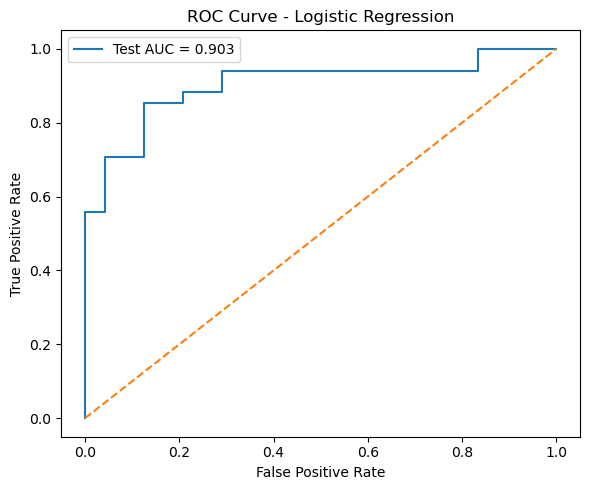

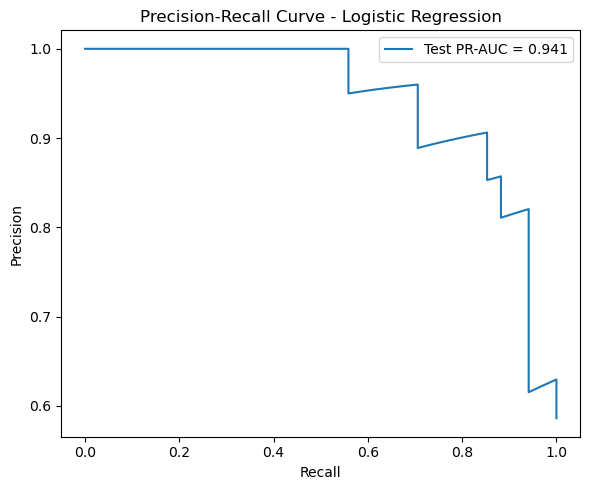


Saved: merged_logreg_test_predictions.csv

Saved files:
- merged_logreg_threshold_tuning.csv
- merged_logreg_roc_curve.png
- merged_logreg_pr_curve.png
- merged_logreg_test_predictions.csv
- merged_logreg_summary.csv


In [2]:
# =========================================
# 1) Imports
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import ConvertToNumpyArray

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    balanced_accuracy_score,
    average_precision_score
)

# =========================================
# 2) Read merged train/test sets
# =========================================
train_file = "merged_train_set.csv"
test_file = "merged_test_set.csv"

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

train_df["Smiles"] = train_df["Smiles"].astype(str).str.strip()
test_df["Smiles"] = test_df["Smiles"].astype(str).str.strip()

train_df["Label"] = pd.to_numeric(train_df["Label"], errors="coerce")
test_df["Label"] = pd.to_numeric(test_df["Label"], errors="coerce")

train_df = train_df.dropna(subset=["Smiles", "Label"]).copy()
test_df = test_df.dropna(subset=["Smiles", "Label"]).copy()

train_df["Label"] = train_df["Label"].astype(int)
test_df["Label"] = test_df["Label"].astype(int)

print("Train shape:", train_df.shape)
print(train_df["Label"].value_counts().sort_index())

print("\nTest shape:", test_df.shape)
print(test_df["Label"].value_counts().sort_index())

# =========================================
# 3) Convert SMILES to Morgan fingerprints
# =========================================
def smiles_to_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.int8)
    ConvertToNumpyArray(fp, arr)
    return arr

def build_feature_matrix(df, smiles_col="Smiles", label_col="Label"):
    X, y, kept_idx = [], [], []
    for idx, (smi, label) in enumerate(zip(df[smiles_col], df[label_col])):
        fp = smiles_to_fp(smi)
        if fp is not None:
            X.append(fp)
            y.append(int(label))
            kept_idx.append(idx)
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)
    return X, y, kept_idx

X_train, y_train, train_kept = build_feature_matrix(train_df)
X_test, y_test, test_kept = build_feature_matrix(test_df)

train_df_valid = train_df.iloc[train_kept].copy().reset_index(drop=True)
test_df_valid = test_df.iloc[test_kept].copy().reset_index(drop=True)

print("\nUsable train samples:", X_train.shape[0])
print("Usable test samples:", X_test.shape[0])

# =========================================
# 4) Train Logistic Regression
# =========================================
model = LogisticRegression(
    C=100,
    penalty="l2",
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel training completed.")

# =========================================
# 5) Predictions
# =========================================
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_05 = (y_prob >= 0.5).astype(int)

print("\n================ TEST RESULTS (0.5 threshold) ================")
print("Test Accuracy:", accuracy_score(y_test, y_pred_05))
print("Test Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_05))
print("Test F1-score:", f1_score(y_test, y_pred_05))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Test PR-AUC (Average Precision):", average_precision_score(y_test, y_prob))

print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_05, digits=3))

print("Test Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_05))

print("\nPredicted test labels:")
print(pd.Series(y_pred_05).value_counts().sort_index())

# =========================================
# 6) Threshold tuning on train probabilities
# =========================================
y_train_prob = model.predict_proba(X_train)[:, 1]

thresholds = np.arange(0.30, 0.91, 0.05)
best_threshold = 0.5
best_f1 = -1

threshold_rows = []

for t in thresholds:
    pred_t = (y_train_prob >= t).astype(int)
    f1_t = f1_score(y_train, pred_t)
    bal_acc_t = balanced_accuracy_score(y_train, pred_t)

    threshold_rows.append({
        "threshold": round(float(t), 2),
        "train_f1": f1_t,
        "train_balanced_accuracy": bal_acc_t,
        "pred_0": int((pred_t == 0).sum()),
        "pred_1": int((pred_t == 1).sum())
    })

    if f1_t > best_f1:
        best_f1 = f1_t
        best_threshold = float(t)

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv("merged_logreg_threshold_tuning.csv", index=False)

print("\nSaved: merged_logreg_threshold_tuning.csv")
print("Best threshold from training probabilities:", best_threshold)

# تطبيق أفضل threshold على test
y_pred_best = (y_prob >= best_threshold).astype(int)

print("\n================ TEST RESULTS (best threshold) ================")
print("Threshold:", best_threshold)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("Test Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_best))
print("Test F1-score:", f1_score(y_test, y_pred_best))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Test PR-AUC (Average Precision):", average_precision_score(y_test, y_prob))

print("\nTest Classification Report (Best Threshold):")
print(classification_report(y_test, y_pred_best, digits=3))

print("Test Confusion Matrix (Best Threshold):")
print(confusion_matrix(y_test, y_pred_best))

print("\nPredicted test labels (Best Threshold):")
print(pd.Series(y_pred_best).value_counts().sort_index())

# =========================================
# 7) ROC curve
# =========================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Test AUC = {roc_auc_val:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Test AUC = {roc_auc_val:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.savefig("merged_logreg_roc_curve.png", dpi=300, bbox_inches="tight")
plt.close()

# =========================================
# 8) PR curve
# =========================================
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"Test PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"Test PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.savefig("merged_logreg_pr_curve.png", dpi=300, bbox_inches="tight")
plt.close()

# =========================================
# 9) Save predictions
# =========================================
test_results = test_df_valid.copy().reset_index(drop=True)
test_results["y_true"] = y_test
test_results["y_prob"] = y_prob
test_results["y_pred_0.5"] = y_pred_05
test_results["y_pred_best_threshold"] = y_pred_best

test_results.to_csv("merged_logreg_test_predictions.csv", index=False)
print("\nSaved: merged_logreg_test_predictions.csv")

# =========================================
# 10) Save final summary
# =========================================
summary = pd.DataFrame([{
    "train_size": len(train_df_valid),
    "test_size": len(test_df_valid),
    "best_threshold": best_threshold,
    "test_accuracy_0.5": accuracy_score(y_test, y_pred_05),
    "test_balanced_accuracy_0.5": balanced_accuracy_score(y_test, y_pred_05),
    "test_f1_0.5": f1_score(y_test, y_pred_05),
    "test_roc_auc": roc_auc_score(y_test, y_prob),
    "test_pr_auc_average_precision": average_precision_score(y_test, y_prob),
    "test_accuracy_best_threshold": accuracy_score(y_test, y_pred_best),
    "test_balanced_accuracy_best_threshold": balanced_accuracy_score(y_test, y_pred_best),
    "test_f1_best_threshold": f1_score(y_test, y_pred_best)
}])

summary.to_csv("merged_logreg_summary.csv", index=False)

print("\nSaved files:")
print("- merged_logreg_threshold_tuning.csv")
print("- merged_logreg_roc_curve.png")
print("- merged_logreg_pr_curve.png")
print("- merged_logreg_test_predictions.csv")
print("- merged_logreg_summary.csv")

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_prob = rf_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


=== Random Forest ===
Accuracy: 0.8275862068965517
Balanced Accuracy: 0.8345588235294117
F1-score: 0.84375
ROC-AUC: 0.8927696078431373
PR-AUC: 0.9268415795996029
              precision    recall  f1-score   support

           0       0.75      0.88      0.81        24
           1       0.90      0.79      0.84        34

    accuracy                           0.83        58
   macro avg       0.82      0.83      0.83        58
weighted avg       0.84      0.83      0.83        58

[[21  3]
 [ 7 27]]


In [4]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_prob = gb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Gradient Boosting ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


=== Gradient Boosting ===
Accuracy: 0.8103448275862069
Balanced Accuracy: 0.8198529411764706
F1-score: 0.8253968253968255
ROC-AUC: 0.8664215686274509
PR-AUC: 0.92846759584876
              precision    recall  f1-score   support

           0       0.72      0.88      0.79        24
           1       0.90      0.76      0.83        34

    accuracy                           0.81        58
   macro avg       0.81      0.82      0.81        58
weighted avg       0.83      0.81      0.81        58

[[21  3]
 [ 8 26]]


In [7]:
import pandas as pd

df_merged = pd.read_csv("merged_curated_dataset.csv")

print(df_merged.shape)
df_merged.head()

(286, 54)


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Properties,Action Type,Standard Text Value,Value,Value_nM,Label,Original_Source,Source,Activity_Type,Activity_Value
0,CHEMBL505308,NaN,NaN,NaN,NaN,NaN,NaN,Br.Oc1cc2c(cc1O)C(c1ccccc1)CNCC2,Inhibition,'=',...,NaN,NaN,NaN,NaN,NaN,0,external,external_inhibition,Inhibition_%,5.0
1,CHEMBL4303154,NaN,NaN,NaN,NaN,NaN,NaN,C/C=C1\C(OC2OC(CO)C(O)C(O)C2O)OC=C(C(=O)OC)C1C...,Inhibition,'=',...,NaN,NaN,NaN,NaN,NaN,0,external,external_inhibition,Inhibition_%,0.0
2,CHEMBL1188627,NaN,NaN,NaN,NaN,NaN,NaN,C/N=c1/nc(-c2ccccc2)n(-c2ccccc2)s1,Inhibition,'=',...,NaN,NaN,NaN,NaN,NaN,0,external,external_inhibition,Inhibition_%,44.0
3,CHEMBL154580,NaN,NaN,NaN,NaN,NaN,NaN,C=CC(=O)c1ccc2ccccc2c1,Inhibition,'=',...,NaN,NaN,NaN,NaN,NaN,0,external,external_inhibition,Inhibition_%,26.0
4,CHEMBL5604436,NaN,NaN,365.83,0.0,4.13,ASAP-0027832,C=CC[C@H](Nc1cccc(-c2nn[nH]n2)c1)c1cc(Cl)cc2[n...,EC50,=,...,Baseline response = 0.0 % | EC50 CI (lower) = ...,NaN,NaN,0.988,988.0,1,training,NaN,NaN,NaN


In [8]:
from sklearn.model_selection import train_test_split

# df_merged هو البيانات بعد الدمج وإزالة التكرار

train_df, external_df = train_test_split(
    df_merged,
    test_size=0.2,        # 20% خارجي
    stratify=df_merged["Label"],
    random_state=42
)

print("Train size:", train_df.shape)
print("External size:", external_df.shape)

Train size: (228, 54)
External size: (58, 54)


In [9]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["Label"],
    random_state=42
)

print("Train final:", train_df.shape)
print("Validation:", val_df.shape)

Train final: (182, 54)
Validation: (46, 54)


In [10]:
X_train, y_train = [], []
for smi, label in zip(train_df["Smiles"], train_df["Label"]):
    fp = smiles_to_fp(smi)
    if fp is not None:
        X_train.append(fp)
        y_train.append(label)

X_val, y_val = [], []
for smi, label in zip(val_df["Smiles"], val_df["Label"]):
    fp = smiles_to_fp(smi)
    if fp is not None:
        X_val.append(fp)
        y_val.append(label)

X_ext, y_ext = [], []
for smi, label in zip(external_df["Smiles"], external_df["Label"]):
    fp = smiles_to_fp(smi)
    if fp is not None:
        X_ext.append(fp)
        y_ext.append(label)

import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
X_val, y_val = np.array(X_val), np.array(y_val)
X_ext, y_ext = np.array(X_ext), np.array(y_ext)

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [12]:
from sklearn.metrics import *

y_val_prob = model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.5).astype(int)

print("Validation:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))
print(classification_report(y_val, y_val_pred))

Validation:
Accuracy: 0.717391304347826
F1: 0.7719298245614035
ROC-AUC: 0.7914230019493177
              precision    recall  f1-score   support

           0       0.69      0.58      0.63        19
           1       0.73      0.81      0.77        27

    accuracy                           0.72        46
   macro avg       0.71      0.70      0.70        46
weighted avg       0.71      0.72      0.71        46



In [13]:
y_ext_prob = model.predict_proba(X_ext)[:, 1]
y_ext_pred = (y_ext_prob >= 0.5).astype(int)

print("\n=== EXTERNAL RESULTS ===")
print("Accuracy:", accuracy_score(y_ext, y_ext_pred))
print("F1:", f1_score(y_ext, y_ext_pred))
print("ROC-AUC:", roc_auc_score(y_ext, y_ext_prob))
print("PR-AUC:", average_precision_score(y_ext, y_ext_prob))

print(classification_report(y_ext, y_ext_pred))
print(confusion_matrix(y_ext, y_ext_pred))


=== EXTERNAL RESULTS ===
Accuracy: 0.7413793103448276
F1: 0.7619047619047619
ROC-AUC: 0.8480392156862744
PR-AUC: 0.88010579534404
              precision    recall  f1-score   support

           0       0.66      0.79      0.72        24
           1       0.83      0.71      0.76        34

    accuracy                           0.74        58
   macro avg       0.74      0.75      0.74        58
weighted avg       0.76      0.74      0.74        58

[[19  5]
 [10 24]]


In [14]:
train_df.to_csv("train_set.csv", index=False)
external_df.to_csv("external_set.csv", index=False)

print("Saved train_set.csv and external_set.csv")

Saved train_set.csv and external_set.csv


In [15]:
import numpy as np

np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)

np.save("X_val.npy", X_val)
np.save("y_val.npy", y_val)

np.save("X_ext.npy", X_ext)
np.save("y_ext.npy", y_ext)

print("Fingerprints saved successfully")

Fingerprints saved successfully


In [16]:
import pandas as pd

summary = pd.DataFrame({
    "dataset": ["train", "val", "external"],
    "size": [len(X_train), len(X_val), len(X_ext)],
    "active_ratio": [
        y_train.mean(),
        y_val.mean(),
        y_ext.mean()
    ]
})

summary.to_csv("dataset_summary.csv", index=False)

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": ["balanced"]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best RF CV score:", grid_rf.best_score_)
best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best RF CV score: 0.7963981849120817


In [20]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix

y_val_prob = best_rf.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.5).astype(int)

print("=== RF Validation ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))
print("PR-AUC:", average_precision_score(y_val, y_val_prob))
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

=== RF Validation ===
Accuracy: 0.717391304347826
F1: 0.7719298245614035
ROC-AUC: 0.8226120857699805
PR-AUC: 0.88415356495572
              precision    recall  f1-score   support

           0       0.69      0.58      0.63        19
           1       0.73      0.81      0.77        27

    accuracy                           0.72        46
   macro avg       0.71      0.70      0.70        46
weighted avg       0.71      0.72      0.71        46

[[11  8]
 [ 5 22]]


In [21]:
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"],
    "max_iter": [2000]
}

lr = LogisticRegression(random_state=42)

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_lr.fit(X_train, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best LR CV score:", grid_lr.best_score_)
best_lr = grid_lr.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best LR params: {'C': 0.01, 'class_weight': None, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR CV score: 0.7932276214833759


In [22]:
y_val_prob = best_lr.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.5).astype(int)

print("=== LR Validation ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))
print("PR-AUC:", average_precision_score(y_val, y_val_prob))
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

=== LR Validation ===
Accuracy: 0.6739130434782609
F1: 0.7692307692307692
ROC-AUC: 0.6140350877192983
PR-AUC: 0.7073430202130364
              precision    recall  f1-score   support

           0       0.75      0.32      0.44        19
           1       0.66      0.93      0.77        27

    accuracy                           0.67        46
   macro avg       0.70      0.62      0.61        46
weighted avg       0.70      0.67      0.64        46

[[ 6 13]
 [ 2 25]]


In [23]:
results = []

# RF
y_val_prob_rf = best_rf.predict_proba(X_val)[:, 1]
y_val_pred_rf = (y_val_prob_rf >= 0.5).astype(int)

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_val, y_val_pred_rf),
    "F1": f1_score(y_val, y_val_pred_rf),
    "ROC-AUC": roc_auc_score(y_val, y_val_prob_rf),
    "PR-AUC": average_precision_score(y_val, y_val_prob_rf)
})

# LR
y_val_prob_lr = best_lr.predict_proba(X_val)[:, 1]
y_val_pred_lr = (y_val_prob_lr >= 0.5).astype(int)

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_val, y_val_pred_lr),
    "F1": f1_score(y_val, y_val_pred_lr),
    "ROC-AUC": roc_auc_score(y_val, y_val_prob_lr),
    "PR-AUC": average_precision_score(y_val, y_val_prob_lr)
})

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

results_df.to_csv("cv_tuning_validation_results.csv", index=False)
print("Saved: cv_tuning_validation_results.csv")

                 Model  Accuracy        F1   ROC-AUC    PR-AUC
0        Random Forest  0.717391  0.771930  0.822612  0.884154
1  Logistic Regression  0.673913  0.769231  0.614035  0.707343
Saved: cv_tuning_validation_results.csv


In [25]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.001],
    "kernel": ["rbf"],
    "class_weight": [None, "balanced"],
    "probability": [True]
}

svm = SVC(random_state=42)

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_svm.fit(X_train, y_train)

print("Best SVM params:", grid_svm.best_params_)
print("Best SVM CV score:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best SVM params: {'C': 1, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf', 'probability': True}
Best SVM CV score: 0.793252122554448


In [26]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, classification_report, confusion_matrix
)

y_val_prob = best_svm.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.5).astype(int)

print("=== SVM Validation ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))
print("PR-AUC:", average_precision_score(y_val, y_val_prob))
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

=== SVM Validation ===
Accuracy: 0.6739130434782609
F1: 0.7457627118644067
ROC-AUC: 0.7894736842105263
PR-AUC: 0.8635706053029277
              precision    recall  f1-score   support

           0       0.64      0.47      0.55        19
           1       0.69      0.81      0.75        27

    accuracy                           0.67        46
   macro avg       0.67      0.64      0.65        46
weighted avg       0.67      0.67      0.66        46

[[ 9 10]
 [ 5 22]]


In [27]:
import pandas as pd

results = []

# RF
y_val_prob_rf = best_rf.predict_proba(X_val)[:, 1]
y_val_pred_rf = (y_val_prob_rf >= 0.5).astype(int)

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_val, y_val_pred_rf),
    "F1": f1_score(y_val, y_val_pred_rf),
    "ROC-AUC": roc_auc_score(y_val, y_val_prob_rf),
    "PR-AUC": average_precision_score(y_val, y_val_prob_rf)
})

# LR
y_val_prob_lr = best_lr.predict_proba(X_val)[:, 1]
y_val_pred_lr = (y_val_prob_lr >= 0.5).astype(int)

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_val, y_val_pred_lr),
    "F1": f1_score(y_val, y_val_pred_lr),
    "ROC-AUC": roc_auc_score(y_val, y_val_prob_lr),
    "PR-AUC": average_precision_score(y_val, y_val_prob_lr)
})

# SVM
y_val_prob_svm = best_svm.predict_proba(X_val)[:, 1]
y_val_pred_svm = (y_val_prob_svm >= 0.5).astype(int)

results.append({
    "Model": "SVM (RBF)",
    "Accuracy": accuracy_score(y_val, y_val_pred_svm),
    "F1": f1_score(y_val, y_val_pred_svm),
    "ROC-AUC": roc_auc_score(y_val, y_val_prob_svm),
    "PR-AUC": average_precision_score(y_val, y_val_prob_svm)
})

results_df = pd.DataFrame(results)
print(results_df)

results_df.to_csv("three_models_validation_results.csv", index=False)
print("Saved: three_models_validation_results.csv")

                 Model  Accuracy        F1   ROC-AUC    PR-AUC
0        Random Forest  0.717391  0.771930  0.822612  0.884154
1  Logistic Regression  0.673913  0.769231  0.614035  0.707343
2            SVM (RBF)  0.673913  0.745763  0.789474  0.863571
Saved: three_models_validation_results.csv


In [28]:
pip install xgboost

In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import *

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Validation
y_val_prob = xgb_model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_prob >= 0.5).astype(int)

print("=== XGBoost Validation ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))
print("PR-AUC:", average_precision_score(y_val, y_val_prob))
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

=== XGBoost Validation ===
Accuracy: 0.8043478260869565
F1: 0.8421052631578948
ROC-AUC: 0.8557504873294347
PR-AUC: 0.900748663692833
              precision    recall  f1-score   support

           0       0.81      0.68      0.74        19
           1       0.80      0.89      0.84        27

    accuracy                           0.80        46
   macro avg       0.81      0.79      0.79        46
weighted avg       0.81      0.80      0.80        46

[[13  6]
 [ 3 24]]


In [31]:
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_val, y_val_pred),
    "F1": f1_score(y_val, y_val_pred),
    "ROC-AUC": roc_auc_score(y_val, y_val_prob),
    "PR-AUC": average_precision_score(y_val, y_val_prob)
})

In [32]:
y_ext_prob = xgb_model.predict_proba(X_ext)[:, 1]
y_ext_pred = (y_ext_prob >= 0.5).astype(int)

print("=== XGBoost External ===")
print("Accuracy:", accuracy_score(y_ext, y_ext_pred))
print("F1:", f1_score(y_ext, y_ext_pred))
print("ROC-AUC:", roc_auc_score(y_ext, y_ext_prob))
print("PR-AUC:", average_precision_score(y_ext, y_ext_prob))

=== XGBoost External ===
Accuracy: 0.7413793103448276
F1: 0.7692307692307693
ROC-AUC: 0.7708333333333333
PR-AUC: 0.8142352639943599


In [33]:
import joblib
joblib.dump(xgb_model, "final_xgboost_model.pkl")

['final_xgboost_model.pkl']

In [35]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

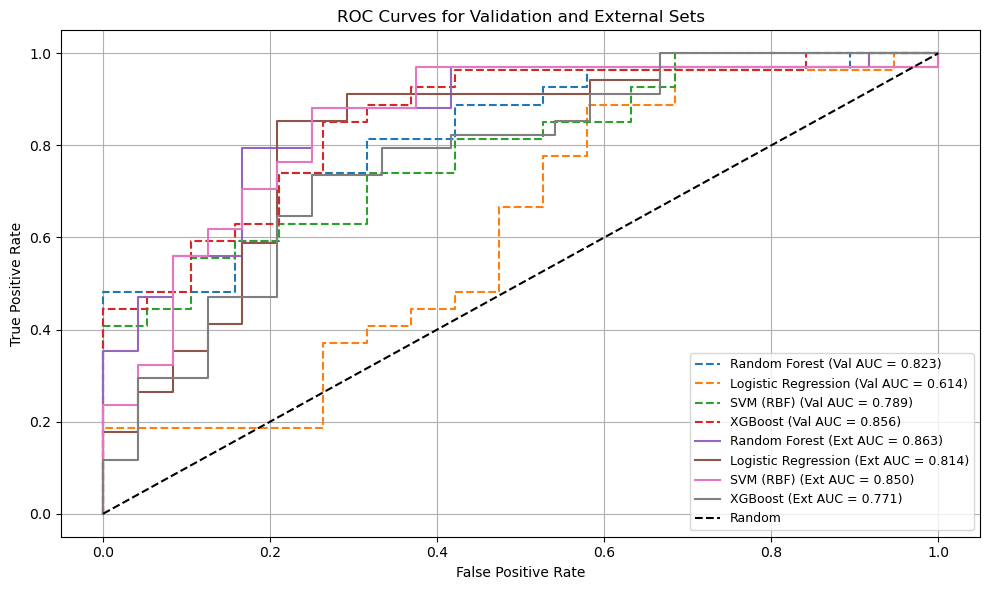

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

# =========================
# Validation ROC
# =========================
models_val = {
    "Random Forest": (best_rf, X_val, y_val),
    "Logistic Regression": (best_lr, X_val, y_val),
    "SVM (RBF)": (best_svm, X_val, y_val),
    "XGBoost": (xgb_model, X_val, y_val)
}

for name, (model, X, y) in models_val.items():
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        linestyle="--",
        label=f"{name} (Val AUC = {roc_auc:.3f})"
    )

# =========================
# External ROC
# =========================
models_ext = {
    "Random Forest": (best_rf, X_ext, y_ext),
    "Logistic Regression": (best_lr, X_ext, y_ext),
    "SVM (RBF)": (best_svm, X_ext, y_ext),
    "XGBoost": (xgb_model, X_ext, y_ext)
}

for name, (model, X, y) in models_ext.items():
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        linestyle="-",
        label=f"{name} (Ext AUC = {roc_auc:.3f})"
    )

# خط الأداء العشوائي
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Validation and External Sets")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)

plt.tight_layout()
plt.savefig("roc_all_models_validation_external.png", dpi=300, bbox_inches="tight")
plt.show()

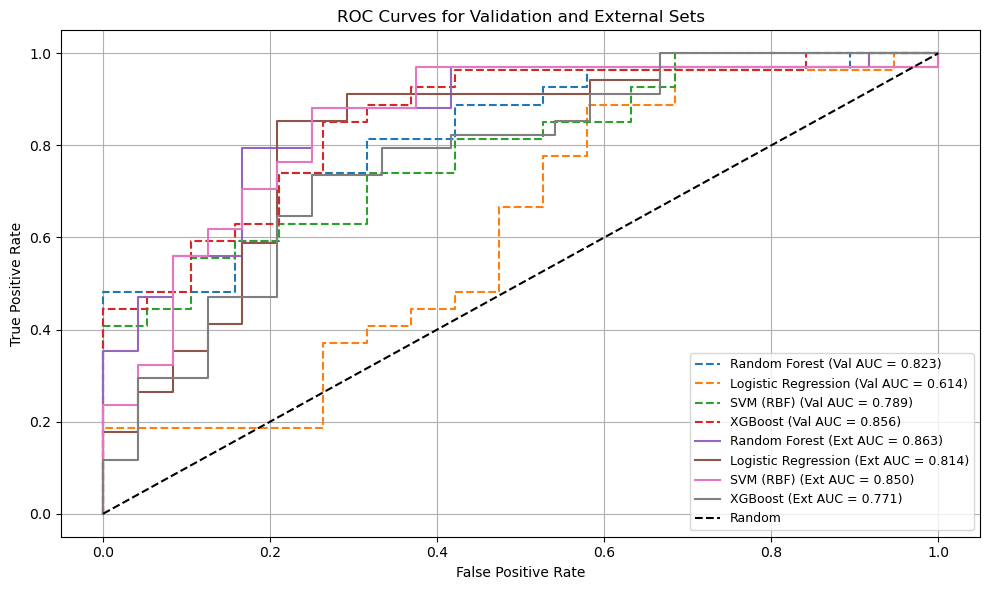

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

# =========================
# Validation ROC
# =========================
models_val = {
    "Random Forest": (best_rf, X_val, y_val),
    "Logistic Regression": (best_lr, X_val, y_val),
    "SVM (RBF)": (best_svm, X_val, y_val),
    "XGBoost": (xgb_model, X_val, y_val)
}

for name, (model, X, y) in models_val.items():
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        linestyle="--",
        label=f"{name} (Val AUC = {roc_auc:.3f})"
    )

# =========================
# External ROC
# =========================
models_ext = {
    "Random Forest": (best_rf, X_ext, y_ext),
    "Logistic Regression": (best_lr, X_ext, y_ext),
    "SVM (RBF)": (best_svm, X_ext, y_ext),
    "XGBoost": (xgb_model, X_ext, y_ext)
}

for name, (model, X, y) in models_ext.items():
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        linestyle="-",
        label=f"{name} (Ext AUC = {roc_auc:.3f})"
    )

# خط الأداء العشوائي
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Validation and External Sets")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)

plt.tight_layout()
plt.savefig("roc_all_models_validation_external.png", dpi=300, bbox_inches="tight")
plt.show()

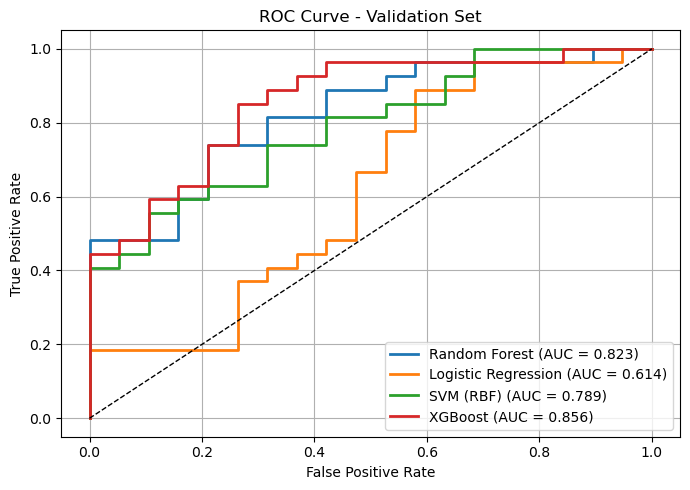

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 5))

models_val = {
    "Random Forest": (best_rf, X_val, y_val),
    "Logistic Regression": (best_lr, X_val, y_val),
    "SVM (RBF)": (best_svm, X_val, y_val),
    "XGBoost": (xgb_model, X_val, y_val)
}

for name, (model, X, y) in models_val.items():
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")

# خط عشوائي
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation Set")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.savefig("validation_roc.png", dpi=300)
plt.show()

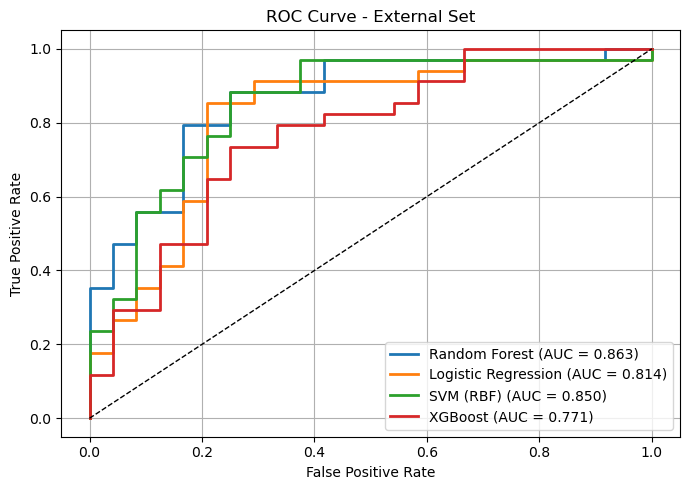

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 5))

models_ext = {
    "Random Forest": (best_rf, X_ext, y_ext),
    "Logistic Regression": (best_lr, X_ext, y_ext),
    "SVM (RBF)": (best_svm, X_ext, y_ext),
    "XGBoost": (xgb_model, X_ext, y_ext)
}

for name, (model, X, y) in models_ext.items():
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")

# خط عشوائي
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - External Set")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.savefig("external_roc.png", dpi=300)
plt.show()

In [41]:
import joblib
joblib.dump(best_rf, "final_model_rf.pkl")

['final_model_rf.pkl']

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.base import clone

In [3]:
# تحميل البيانات
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")

X_val = np.load("X_val.npy")
y_val = np.load("y_val.npy")

# تحميل الموديل النهائي
best_rf = joblib.load("final_model_rf.pkl")

In [4]:
def evaluate_classifier(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "ROC_AUC": roc_auc_score(y, y_prob),
        "PR_AUC": average_precision_score(y, y_prob)
    }

In [5]:
real_val_results = evaluate_classifier(best_rf, X_val, y_val)
real_val_results

{'Accuracy': 0.717391304347826,
 'F1': 0.7719298245614035,
 'ROC_AUC': 0.8226120857699805,
 'PR_AUC': 0.88415356495572}

In [6]:
n_scrambles = 100
random_state = 42

scramble_results = []

for i in range(n_scrambles):
    rng = np.random.RandomState(random_state + i)
    y_train_scrambled = rng.permutation(y_train)
    
    scrambled_model = clone(best_rf)
    scrambled_model.fit(X_train, y_train_scrambled)
    
    y_val_pred = scrambled_model.predict(X_val)
    y_val_prob = scrambled_model.predict_proba(X_val)[:, 1]
    
    result = {
        "iteration": i + 1,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "F1": f1_score(y_val, y_val_pred),
        "ROC_AUC": roc_auc_score(y_val, y_val_prob),
        "PR_AUC": average_precision_score(y_val, y_val_prob)
    }
    scramble_results.append(result)

scramble_df = pd.DataFrame(scramble_results)
scramble_df.head()

,iteration,Accuracy,F1,ROC_AUC,PR_AUC
0,1,0.608696,0.678571,0.600390,0.715293
1,2,0.652174,0.714286,0.725146,0.831007
2,3,0.673913,0.727273,0.744639,0.843425
3,4,0.391304,0.548387,0.384016,0.576470
4,5,0.652174,0.714286,0.699805,0.765662


In [7]:
print("Real model performance on validation set:")
for k, v in real_val_results.items():
    print(f"{k}: {v:.4f}")

print("\nScrambled mean performance:")
print(scramble_df[["Accuracy", "F1", "ROC_AUC", "PR_AUC"]].mean())

Real model performance on validation set:
Accuracy: 0.7174
F1: 0.7719
ROC_AUC: 0.8226
PR_AUC: 0.8842

Scrambled mean performance:
Accuracy    0.500000
F1          0.595681
ROC_AUC     0.489142
PR_AUC      0.643506
dtype: float64


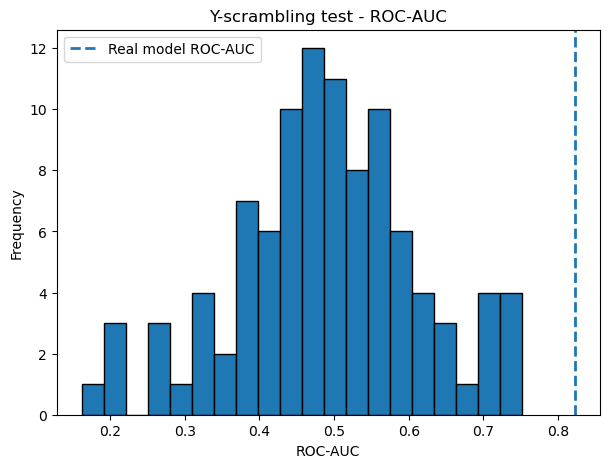

In [38]:
plt.figure(figsize=(7,5))
plt.hist(scramble_df["ROC_AUC"], bins=20, edgecolor="black")
plt.axvline(real_val_results["ROC_AUC"], linestyle="--", linewidth=2, label="Real model ROC-AUC")

plt.xlabel("ROC-AUC")
plt.ylabel("Frequency")
plt.title("Y-scrambling test - ROC-AUC")
plt.legend()

# 👇 هذا هو المهم
plt.savefig("yscrambling_roc_auc.png", dpi=300, bbox_inches="tight")

plt.show()


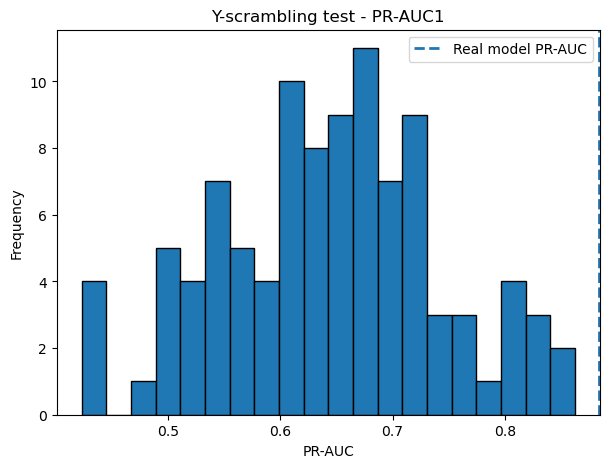

In [37]:
plt.figure(figsize=(7,5))
plt.hist(scramble_df["PR_AUC"], bins=20, edgecolor="black")
plt.axvline(real_val_results["PR_AUC"], linestyle="--", linewidth=2, label="Real model PR-AUC")
plt.xlabel("PR-AUC")
plt.ylabel("Frequency")
plt.title("Y-scrambling test - PR-AUC1")
plt.legend()
plt.show()
fig.savefig("Y-scrambling test - ROC-AUC1.png", dpi=300, bbox_inches="tight")

In [10]:
p_roc = (np.sum(scramble_df["ROC_AUC"] >= real_val_results["ROC_AUC"]) + 1) / (n_scrambles + 1)
p_pr  = (np.sum(scramble_df["PR_AUC"] >= real_val_results["PR_AUC"]) + 1) / (n_scrambles + 1)

print(f"Empirical p-value (ROC-AUC): {p_roc:.4f}")
print(f"Empirical p-value (PR-AUC): {p_pr:.4f}")

Empirical p-value (ROC-AUC): 0.0099
Empirical p-value (PR-AUC): 0.0099


In [11]:
scramble_df.to_csv("y_scrambling_results.csv", index=False)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# 1) Scale features
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# =========================
# 2) PCA for AD calculation
# =========================
# يمكنك تغيير n_components إلى 10 أو 20 أو 30
n_components = 20

pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print("Original feature shape:", X_train.shape)
print("PCA-transformed shape:", X_train_pca.shape)
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

# =========================
# 3) Compute leverage
# =========================
# Add intercept term
X_train_ad = np.hstack([np.ones((X_train_pca.shape[0], 1)), X_train_pca])
X_val_ad = np.hstack([np.ones((X_val_pca.shape[0], 1)), X_val_pca])

# Moore-Penrose pseudo-inverse
XtX_inv = np.linalg.pinv(X_train_ad.T @ X_train_ad)

# Training leverage
H = X_train_ad @ XtX_inv @ X_train_ad.T
h_train = np.diag(H)

# Validation / external leverage
h_val = np.sum((X_val_ad @ XtX_inv) * X_val_ad, axis=1)

# =========================
# 4) Leverage threshold h*
# =========================
n = X_train_ad.shape[0]
p = X_train_ad.shape[1] - 1  # exclude intercept

h_star = 3 * (p + 1) / n
print("Leverage threshold (h*):", h_star)

# =========================
# 5) Predictions + residuals
# =========================
y_val_pred = best_rf.predict(X_val)

# classification residuals
residuals = y_val - y_val_pred

# standardized residuals
std_residuals = (residuals - np.mean(residuals)) / np.std(residuals)

# =========================
# 6) Inside / outside AD
# =========================
inside_ad = (h_val <= h_star) & (np.abs(std_residuals) <= 3)
outside_ad = ~inside_ad

print("Inside AD:", np.sum(inside_ad))
print("Outside AD:", np.sum(outside_ad))
print("Inside AD %:", np.mean(inside_ad) * 100)

# =========================
# 7) Save results table
# =========================
ad_results = pd.DataFrame({
    "y_true": y_val,
    "y_pred": y_val_pred,
    "leverage": h_val,
    "residual": residuals,
    "std_residual": std_residuals,
    "inside_AD": inside_ad
})

ad_results.to_csv("applicability_domain_results.csv", index=False)
ad_results.head()

Original feature shape: (182, 2048)
PCA-transformed shape: (182, 20)
Explained variance ratio sum: 0.3659430895164707
Leverage threshold (h*): 0.34615384615384615
Inside AD: 45
Outside AD: 1
Inside AD %: 97.82608695652173


,y_true,y_pred,leverage,residual,std_residual,inside_AD
0,1,0,0.089337,1,2.019010,True
1,1,1,0.014209,0,0.123613,True
2,0,1,0.026574,-1,-1.771784,True
3,1,1,0.277091,0,0.123613,True
4,0,0,0.009729,0,0.123613,True


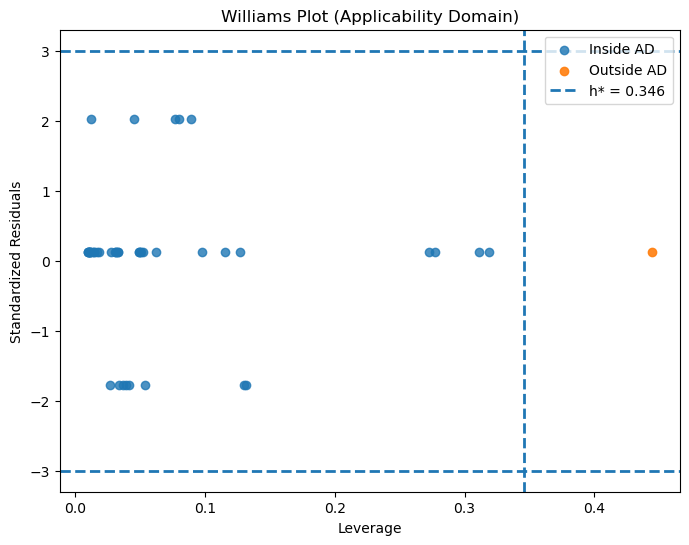

In [22]:
plt.figure(figsize=(8, 6))

# points inside AD
plt.scatter(
    h_val[inside_ad],
    std_residuals[inside_ad],
    alpha=0.8,
    label="Inside AD"
)

# points outside AD
if np.sum(outside_ad) > 0:
    plt.scatter(
        h_val[outside_ad],
        std_residuals[outside_ad],
        alpha=0.9,
        label="Outside AD"
    )

# threshold lines
plt.axvline(h_star, linestyle="--", linewidth=2, label=f"h* = {h_star:.3f}")
plt.axhline(3, linestyle="--", linewidth=2)
plt.axhline(-3, linestyle="--", linewidth=2)

plt.xlabel("Leverage")
plt.ylabel("Standardized Residuals")
plt.title("Williams Plot (Applicability Domain)")
plt.legend()
plt.show()

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# =========================
# 1) Combine train and external
# =========================
X_all = np.vstack([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

set_labels = np.array(
    ["Train"] * len(X_train) + ["External"] * len(X_val)
)

print("Combined shape:", X_all.shape)

# =========================
# 2) Scale data
# =========================
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

# =========================
# 3) t-SNE
# =========================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_all_scaled)

# =========================
# 4) Save results
# =========================
tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "Class": y_all,
    "Set": set_labels
})

tsne_df.to_csv("tsne_results.csv", index=False)
tsne_df.head()

Combined shape: (228, 2048)


C:\Users\user\anaconda3\envs\rdkit_env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,TSNE1,TSNE2,Class,Set
0,4.219388,5.279322,1,Train
1,-3.336777,-3.903972,0,Train
2,0.213339,-0.060568,1,Train
3,-8.176546,3.593297,0,Train
4,-4.591496,8.668683,1,Train


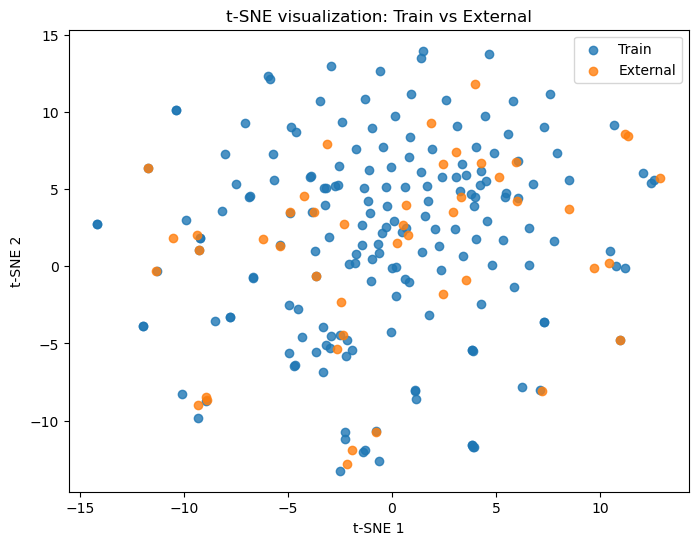

In [24]:
plt.figure(figsize=(8, 6))

for subset in ["Train", "External"]:
    mask = tsne_df["Set"] == subset
    plt.scatter(
        tsne_df.loc[mask, "TSNE1"],
        tsne_df.loc[mask, "TSNE2"],
        alpha=0.8,
        label=subset
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE visualization: Train vs External")
plt.legend()
plt.show()

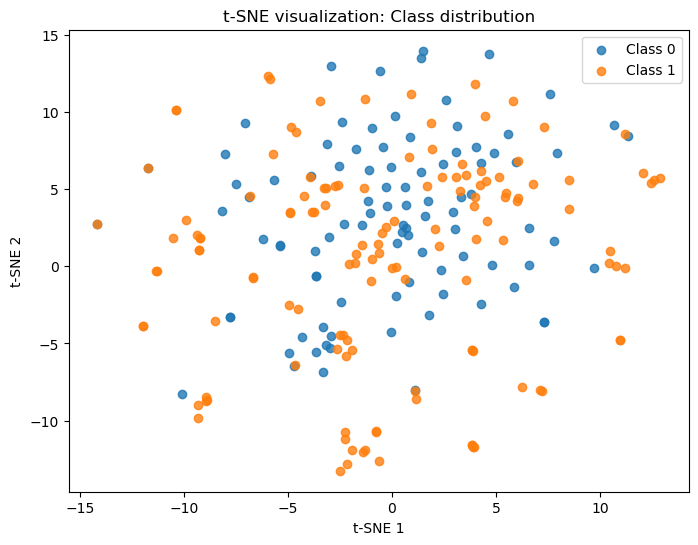

In [25]:
plt.figure(figsize=(8, 6))

for cls in sorted(tsne_df["Class"].unique()):
    mask = tsne_df["Class"] == cls
    plt.scatter(
        tsne_df.loc[mask, "TSNE1"],
        tsne_df.loc[mask, "TSNE2"],
        alpha=0.8,
        label=f"Class {cls}"
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE visualization: Class distribution")
plt.legend()
plt.show()

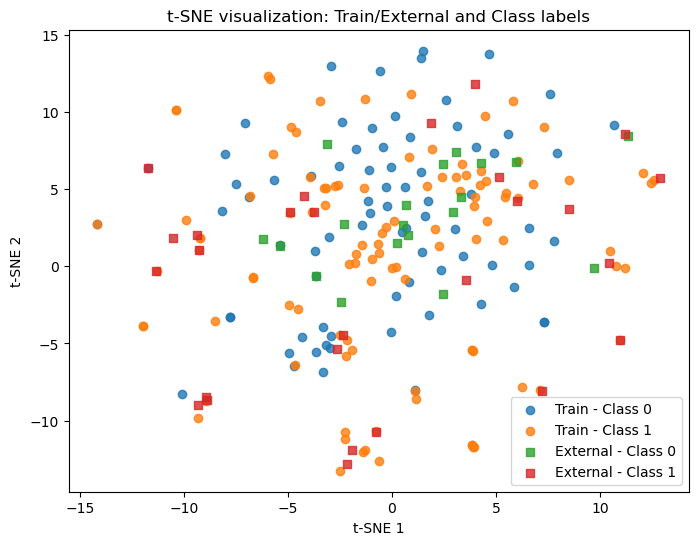

<Figure size 640x480 with 0 Axes>

In [30]:
plt.figure(figsize=(8, 6))

markers = {"Train": "o", "External": "s"}

for subset in ["Train", "External"]:
    for cls in sorted(tsne_df["Class"].unique()):
        mask = (tsne_df["Set"] == subset) & (tsne_df["Class"] == cls)
        plt.scatter(
            tsne_df.loc[mask, "TSNE1"],
            tsne_df.loc[mask, "TSNE2"],
            alpha=0.8,
            marker=markers[subset],
            label=f"{subset} - Class {cls}"
        )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE visualization: Train/External and Class labels")
plt.legend()
plt.show()
plt.savefig("tsne_plot.png", dpi=300, bbox_inches="tight")
plt.show()

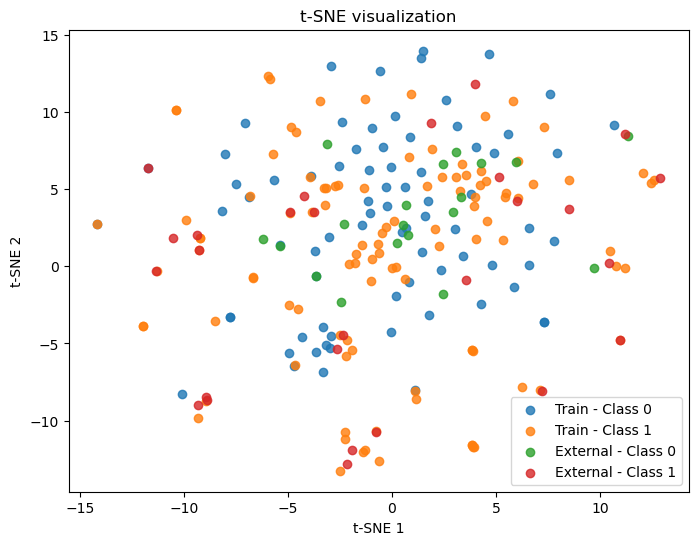

In [31]:
fig, ax = plt.subplots(figsize=(8,6))

for subset in ["Train", "External"]:
    for cls in sorted(tsne_df["Class"].unique()):
        mask = (tsne_df["Set"] == subset) & (tsne_df["Class"] == cls)
        ax.scatter(
            tsne_df.loc[mask, "TSNE1"],
            tsne_df.loc[mask, "TSNE2"],
            alpha=0.8,
            label=f"{subset} - Class {cls}"
        )

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE visualization")

ax.legend()

# حفظ قبل العرض
fig.savefig("tsne_plot.png", dpi=300, bbox_inches="tight")

plt.show()

Plot saved to: C:\Users\user\results\williams_plot.png
CSV saved to: C:\Users\user\results\applicability_domain_results.csv


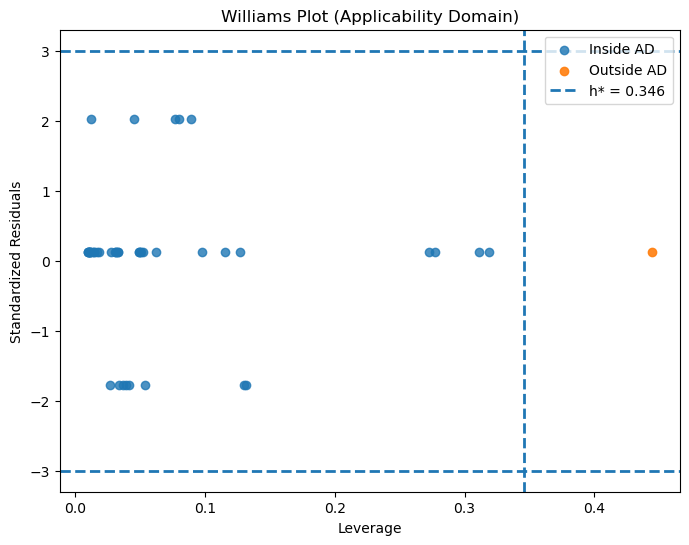

In [32]:
import os
os.makedirs("results", exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    h_val[inside_ad],
    std_residuals[inside_ad],
    alpha=0.8,
    label="Inside AD"
)

if np.sum(outside_ad) > 0:
    ax.scatter(
        h_val[outside_ad],
        std_residuals[outside_ad],
        alpha=0.9,
        label="Outside AD"
    )

ax.axvline(h_star, linestyle="--", linewidth=2, label=f"h* = {h_star:.3f}")
ax.axhline(3, linestyle="--", linewidth=2)
ax.axhline(-3, linestyle="--", linewidth=2)

ax.set_xlabel("Leverage")
ax.set_ylabel("Standardized Residuals")
ax.set_title("Williams Plot (Applicability Domain)")
ax.legend()

fig.savefig("results/williams_plot.png", dpi=300, bbox_inches="tight")
ad_results.to_csv("results/applicability_domain_results.csv", index=False)

print("Plot saved to:", os.path.abspath("results/williams_plot.png"))
print("CSV saved to:", os.path.abspath("results/applicability_domain_results.csv"))
# حفظ قبل العرض
fig.savefig("tsne_plot.png", dpi=300, bbox_inches="tight")

plt.show()

plt.show()

In [1]:
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("train_set.csv")

print(df.head())

  Molecule ChEMBL ID Molecule Name  Molecule Max Phase  Molecular Weight  \
0      CHEMBL4779802           NaN                 NaN            419.41   
1      CHEMBL3810058           NaN                 NaN               NaN   
2      CHEMBL4554138           NaN                 NaN            416.73   
3       CHEMBL154580           NaN                 NaN               NaN   
4      CHEMBL3137745           NaN                 NaN            428.79   

   #RO5 Violations  AlogP Compound Key  \
0              1.0   5.88           33   
1              NaN    NaN          NaN   
2              1.0   5.42           6d   
3              NaN    NaN          NaN   
4              1.0   5.18           45   

                                              Smiles Standard Type  \
0  N#Cc1ccc(CNc2ccc3ncnc(Nc4ccc(C(F)(F)F)cc4)c3c2...          IC50   
1  O=C1/C(=C\c2ccc(-c3ccccc3)o2)C(c2ccccc2)=NN1c1...          IC50   
2  CC(=O)c1c(Nc2ccc(F)cc2F)[nH]c2c(C(F)(F)F)cc(Cl...          IC50   
3         

In [3]:
def smiles_to_ecfp4(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    arr = np.array(fp)
    return arr

In [10]:
import numpy as np

X_train = np.load("X_train.npy")
X_val   = np.load("X_val.npy")
X_ext   = np.load("X_ext.npy")

y_ext   = np.load("y_ext.npy")

print(X_train.shape, X_val.shape, X_ext.shape)

(182, 2048) (46, 2048) (58, 2048)


In [9]:
!pip install scikit-learn==1.4.2 umap-learn==0.5.5

  Using cached scikit_learn-1.4.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Using cached scikit_learn-1.4.2-cp310-cp310-win_amd64.whl (10.6 MB)
  Created wheel for umap-learn: filename=umap_learn-0.5.5-py3-none-any.whl size=87026 sha256=36307d4ec8033399232cb4277e279aa15b4ba71118d8343e8682f1692fffba12
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\3a\70\07\428d2b58660a1a3b431db59b806a10da736612ebbc66c1bcc5
Successfully built umap-learn

  Attempting uninstall: scikit-learn

    Found existing installation: scikit-learn 1.3.0

   ---------------------------------------- 0/2 [scikit-learn]
    Uninstalling scikit-learn-1.3.0:
   --------------

  You can safely remove it manually.


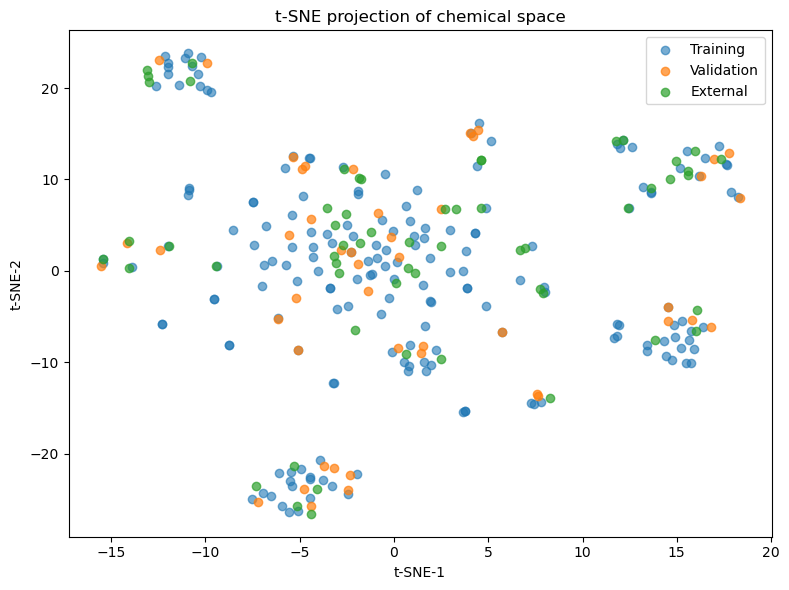

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# دمج البيانات
X_all = np.vstack([X_train, X_val, X_ext]).astype(np.float32)

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X_all)

# تقسيم الإحداثيات
n_train = len(X_train)
n_val = len(X_val)

X_train_tsne = X_tsne[:n_train]
X_val_tsne = X_tsne[n_train:n_train+n_val]
X_ext_tsne = X_tsne[n_train+n_val:]

# الرسم
plt.figure(figsize=(8,6))

plt.scatter(X_train_tsne[:,0], X_train_tsne[:,1], alpha=0.6, label="Training")
plt.scatter(X_val_tsne[:,0], X_val_tsne[:,1], alpha=0.7, label="Validation")
plt.scatter(X_ext_tsne[:,0], X_ext_tsne[:,1], alpha=0.7, label="External")

plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.title("t-SNE projection of chemical space")
plt.legend()
plt.tight_layout()
plt.savefig("tsne_chemical_space.png", dpi=300)
plt.show()